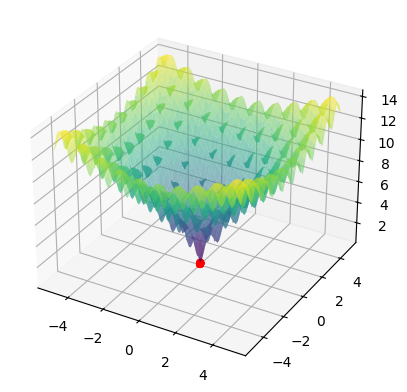

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

POPULATION_SIZE = 100
GENE_LENGTH = 2  
MUTATION_RATE = 0.01
MAX_GENERATIONS = 10

def calculate_diversity(population, tolerance=0.1):
    rounded = [tuple(np.round(ind / tolerance) * tolerance) for ind in population]
    return len(set(rounded))

def calculate_diversity_std(population):
    if len(population) < 2:
        return 0.0
    pop_array = np.array(population)
    return np.mean(np.std(pop_array, axis=0))

def fitness_function(individual):
    x, y = individual
    term1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return term1 + term2 + 20 + np.e

def initialize_population(population_size, gene_length):
    return [np.random.uniform(-5, 5, gene_length) for _ in range(population_size)]

def selection(population, fitness_values):
    selected = []
    for _ in range(2):
        i, j = np.random.choice(len(population), 2, replace=False)
        selected.append(population[i] if fitness_values[i] < fitness_values[j] else population[j])
    return selected[0], selected[1]

def crossover(parent1, parent2):
    alpha = np.random.uniform(0.3, 0.7)
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = (1 - alpha) * parent1 + alpha * parent2
    return child1, child2

def mutate(individual, mutation_rate):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] += np.random.uniform(-0.5, 0.5)
    return individual

def genetic_algorithm():
    fitness_history = [] 
    population = initialize_population(POPULATION_SIZE, GENE_LENGTH)
    populations = [population]
    
    for generation in range(MAX_GENERATIONS):
        fitness_values = [fitness_function(individual) for individual in population]
        
        diversity_unique = calculate_diversity(population, tolerance=0.1)
        diversity_std = calculate_diversity_std(population)
        
        fitness_history.append({
            'generation': generation,
            'avg_fitness': np.mean(fitness_values),
            'max_fitness': np.max(fitness_values),
            'min_fitness': np.min(fitness_values),
            'diversity_unique': diversity_unique,      
            'diversity_std': diversity_std             
        })
        
        new_population = []
        
        while len(new_population) < POPULATION_SIZE:
            parent1, parent2 = selection(population, fitness_values)
            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1, MUTATION_RATE)
            child2 = mutate(child2, MUTATION_RATE)
            new_population.extend([child1, child2])
        
        population = new_population
        populations.append(population)
    
    return populations, fitness_history

def visualize(populations):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = -20 * np.exp(-0.2 * np.sqrt(0.5 * (X**2 + Y**2))) - np.exp(0.5 * (np.cos(2 * np.pi * X) + np.cos(2 * np.pi * Y))) + 20 + np.e
    
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
    
    points = ax.scatter([], [], [], c='r', marker='o')
    
    def update(frame):
        population = populations[frame]
        x_values = [individual[0] for individual in population]
        y_values = [individual[1] for individual in population]
        z_values = [fitness_function(individual) for individual in population]
        points._offsets3d = (x_values, y_values, z_values)
        return points,
    
    anim = FuncAnimation(fig, update, frames=len(populations), interval=200, blit=True)
    
    return HTML(anim.to_jshtml())

populations, _ = genetic_algorithm()
visualize(populations)

In [2]:
def plot_fitness_history(fitness_history):
    generations = [h['generation'] for h in fitness_history]
    avg_fitness = [h['avg_fitness'] for h in fitness_history]
    max_fitness = [h['max_fitness'] for h in fitness_history]
    
    plt.figure(figsize=(10, 6))
    plt.plot(generations, avg_fitness, label='Средняя приспособленность', marker='o', linewidth=2)
    plt.plot(generations, max_fitness, label='Максимальная приспособленность', marker='s', linewidth=2, color='red')
    
    plt.xlabel('Поколение', fontsize=12)
    plt.ylabel('Приспособленность', fontsize=12)
    plt.title('Динамика приспособленности по поколениям', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(generations)
    plt.tight_layout()
    plt.show()

In [3]:
# histories = []
# best_history = None
# worst_history = None
# best_history_val, worst_history_val = 10e9, -10e9

# for i in range(20):
#     populations, fitness_history = genetic_algorithm()
#     histories.append(fitness_history)
#     if fitness_history[9]['avg_fitness'] < best_history_val:
#         best_history = fitness_history[9]['avg_fitness']
#     if fitness_history[9]['avg_fitness'] > worst_history_val:
#         worst_history_val = fitness_history[9]['avg_fitness']

# print(histories[0])
# avg_values = {}
# max_values = {}
# for h in histories:
#     for i in range(len(h)):
#         if 
#         avg_values[]
        
    

In [4]:
def run_multiple_trials(n_trials):
    all_histories = []
    
    for trial in range(n_trials):        
        _, fitness_history = genetic_algorithm()
        all_histories.append(fitness_history)
    
    generations = list(range(len(all_histories[0])))
    
    def aggregate_metric(metric_name):
        values = np.array([[h[metric_name] for h in history] 
                          for history in all_histories])
        return {
            'mean': np.mean(values, axis=0),
            'min': np.min(values, axis=0),
            'max': np.max(values, axis=0),
        }
    
    aggregated = {
        'generations': generations,
        'fitness': {
            'avg': aggregate_metric('avg_fitness'),
            'max': aggregate_metric('max_fitness')
        },
        'diversity': {
            'unique': aggregate_metric('diversity_unique'),
            'std': aggregate_metric('diversity_std')
        }
    }
    
    return aggregated

In [5]:
def plot_fitness_diversity_combined(aggregated):
    gens = aggregated['generations']
    fit_data_max = aggregated['fitness']['max']
    fit_data_avg = aggregated['fitness']['avg']
    div_data_uniq = aggregated['diversity']['unique']
    div_data_std = aggregated['diversity']['std']
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color_fit = 'tab:blue'
    ax1.set_xlabel('Поколение', fontsize=12)
    ax1.set_ylabel('Макс. приспособленность', color=color_fit, fontsize=12)
    ax1.plot(gens, fit_data_max['mean'], label='Макс. приспособленность', 
             color=color_fit, linewidth=2.5, zorder=3)
    ax1.tick_params(axis='y', labelcolor=color_fit)
    ax1.grid(True, alpha=0.3)
    
    ax1.set_xlabel('Поколение', fontsize=12)
    ax1.set_ylabel('Ср. приспособленность', color=color_fit, fontsize=12)
    ax1.plot(gens, fit_data_avg['mean'], label='Ср. приспособленность', 
             color=color_fit, linewidth=2.5, zorder=3)
    ax1.tick_params(axis='y', labelcolor=color_fit)
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    color_div = 'tab:red'
    ax2.set_ylabel('Уникальные особи', color=color_div, fontsize=12)
    ax2.plot(gens, div_data_uniq['mean'], label='Разнообразие (сред.)', 
             color=color_div, linewidth=2.5, zorder=3, marker='o', markersize=3)
    ax2.tick_params(axis='y', labelcolor=color_div)
    ax2.axhline(y=POPULATION_SIZE, color='gray', linestyle='--', alpha=0.3)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)
    
    plt.title('Фитнес и разнообразие', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

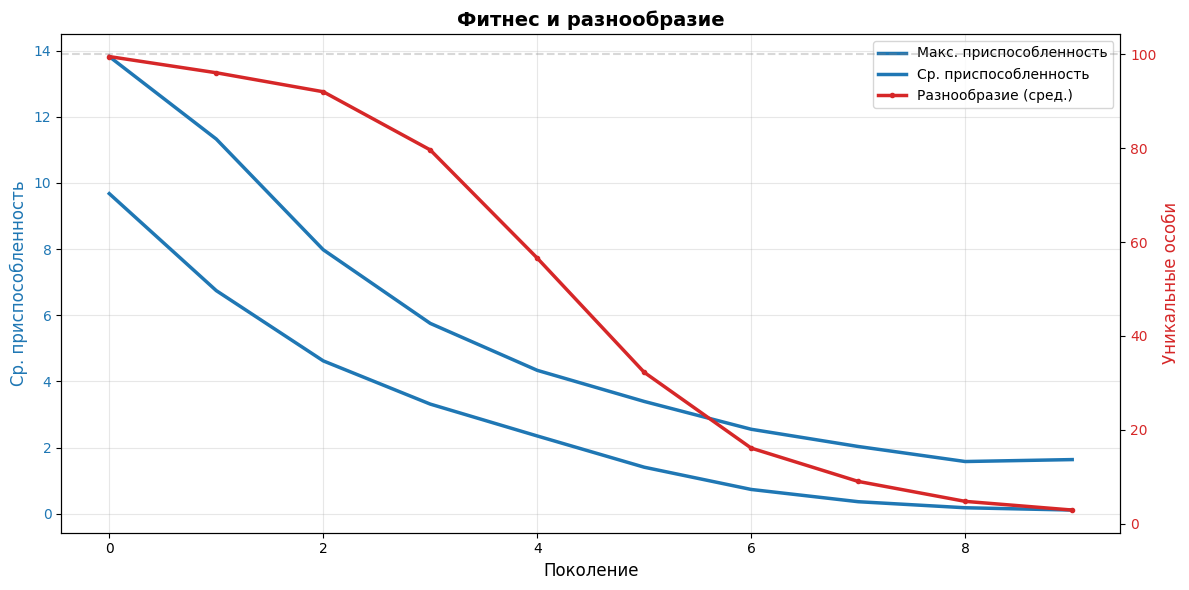

In [6]:
plot_fitness_diversity_combined(run_multiple_trials(20))

In [7]:
# def plot_diversity_history(fitness_history):
#     generations = [h['generation'] for h in fitness_history]
#     diversity_unique = [h['diversity_unique'] for h in fitness_history]
#     diversity_std = [h['diversity_std'] for h in fitness_history]
    
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
#     ax1.plot(generations, diversity_unique, marker='o', color='purple', linewidth=2)
#     ax1.set_ylabel('Уникальные особи', fontsize=10)
#     ax1.set_title('Разнообразие популяции по поколениям', fontsize=14, fontweight='bold')
#     ax1.grid(True, alpha=0.3)
#     ax1.axhline(y=POPULATION_SIZE, color='gray', linestyle='--', alpha=0.5, label='Макс. размер популяции')
#     ax1.legend(fontsize=9)
    
#     ax2.plot(generations, diversity_std, marker='s', color='teal', linewidth=2)
#     ax2.set_xlabel('Поколение', fontsize=12)
#     ax2.set_ylabel('Среднее σ по генам', fontsize=10)
#     ax2.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()